# Baseline Catboost Model

In [2]:
%%capture
! pip install catboost

In [9]:
import pandas as pd, numpy as np, \
seaborn as sns, matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

merged = pd.read_csv('merged.csv', index_col = 0)
merged.head()

,player_id,name_x,position_x,team_x,season_x,conference,usage_passing_downs,usage_standard_downs,usage_third_down,usage_second_down,usage_first_down,usage_rush,usage_var_pass,usage_overall,avg_ppa_passing_downs,avg_ppa_standard_downs,avg_ppa_third_down,avg_ppa_second_down,avg_ppa_first_down,avg_ppa_rush,avg_ppa_var_pass,avg_ppa_all,total_ppa_passing_downs,total_ppa_standard_downs,total_ppa_third_down,total_ppa_second_down,total_ppa_first_down,total_ppa_rush,total_ppa_var_pass,total_ppa_all,fumbles_FUM,fumbles_LOST,fumbles_REC,passing_ATT,passing_COMPLETIONS,passing_INT,passing_PCT,passing_TD,passing_YDS,passing_YPA,receiving_LONG,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_LONG,rushing_TD,rushing_YDS,rushing_YPC,college_athlete_id,nfl_athlete_id,college_id,college_team,college_conference,nfl_team_id,nfl_team,position_y,name_y,year,round_x,pick_number,overall,height_in,weight_lbs,pre_draft_position_ranking,pre_draft_grade,pfr_player_id,cfb_player_id,season_y,round_y,pick,team_y,pfr_player_name,position,category,college,w_av,car_av,dr_av,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle,pfr_id,birth_date,height,weight,rookie_season,last_season,birth_year,age
0,100009,Johnny Jackson,WR,Arizona,2015,PAC,0.104000,0.049000,0.094000,0.065000,0.055000,0.000000,0.133000,0.065000,0.953000,0.413000,1.314000,0.839000,0.415000,NaN,0.674,0.6740,28.600000,13.214000,22.345000,16.772000,9.542000,0.000000,41.813000,41.813000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,50.0,5.0,612.0,12.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,102597,Will Rogers,QB,Washington,2024,B1G,0.670000,0.458333,0.652167,0.532667,0.454333,0.060167,0.888000,0.520333,0.443833,0.188333,0.426833,0.438667,0.138167,-0.1675,0.313,0.2910,57.095833,43.996000,36.587833,45.864333,24.582667,-3.056667,104.148667,101.092333,4.5,2.166667,0.5,336.166667,226.333333,6.166667,0.666333,16.833333,2431.5,7.333333,NaN,NaN,NaN,NaN,NaN,34.000000,17.500000,0.333333,-71.333333,-1.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,107494,Trey Sanders,RB,TCU,2024,B12,0.043400,0.068400,0.047267,0.071533,0.058267,0.119733,0.008867,0.060600,0.646133,0.010467,0.280800,-0.090933,-0.006867,0.1442,NaN,0.1604,2.071933,2.040267,3.381200,-0.835133,-0.067467,3.438600,0.674133,4.112733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.466667,15.333333,2.066667,128.733333,4.173333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109907,Jon Lee,RB,Air Force,2014,MWC,0.035000,0.025000,0.015000,0.057000,0.015000,0.023000,0.052000,0.028000,0.630000,-0.128000,-0.363000,0.173000,0.222000,0.1790,0.015,0.1240,1.890000,-0.770000,-0.363000,1.040000,0.444000,1.076000,0.044000,1.120000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,2.0,0.0,12.0,6.0,6.000000,32.000000,0.000000,39.000000,6.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,136429,Cedric Patterson III,WR,Rice,2022,CUSA,0.077333,0.033667,0.116667,0.018000,0.045000,0.022667,0.086667,0.050667,0.224000,0.066333,0.166000,NaN,0.191333,0.1360,0.150,0.1760,6.349333,6.364667,3.909000,2.029667,6.775333,0.465333,12.248333,12.714000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.666667,15.333333,0.333333,16.000000,7.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
merged.columns

Index(['player_id', 'name_x', 'position_x', 'team_x', 'season_x', 'conference',
       'usage_passing_downs', 'usage_standard_downs', 'usage_third_down',
       'usage_second_down', 'usage_first_down', 'usage_rush', 'usage_var_pass',
       'usage_overall', 'avg_ppa_passing_downs', 'avg_ppa_standard_downs',
       'avg_ppa_third_down', 'avg_ppa_second_down', 'avg_ppa_first_down',
       'avg_ppa_rush', 'avg_ppa_var_pass', 'avg_ppa_all',
       'total_ppa_passing_downs', 'total_ppa_standard_downs',
       'total_ppa_third_down', 'total_ppa_second_down', 'total_ppa_first_down',
       'total_ppa_rush', 'total_ppa_var_pass', 'total_ppa_all', 'fumbles_FUM',
       'fumbles_LOST', 'fumbles_REC', 'passing_ATT', 'passing_COMPLETIONS',
       'passing_INT', 'passing_PCT', 'passing_TD', 'passing_YDS',
       'passing_YPA', 'receiving_LONG', 'receiving_REC', 'receiving_TD',
       'receiving_YDS', 'receiving_YPR', 'rushing_ATT', 'rushing_LONG',
       'rushing_TD', 'rushing_YDS', 'rushing_YPC', 

In [209]:
# filling in NAs for counting stats (they should all be zero)
merged.fillna(value={
    'fumbles_FUM' : 0,
    'fumbles_LOST' : 0,
    'fumbles_REC' : 0,
    'passing_ATT': 0,
    'passing_COMPLETIONS' : 0,
    'passing_PCT' : 0,
    'passing_INT' : 0,
    'passing_TD' : 0,
    'passing_YDS' : 0,
    'passing_YPA' : 0,
    'receiving_LONG' : 0,
    'receiving_REC' : 0,
    'receiving_TD' : 0,
    'receiving_YDS' : 0,
    'receiving_YPR' : 0,
    'rushing_ATT' : 0,
    'rushing_LONG' : 0,
    'rushing_TD' : 0,
    'rushing_YDS' : 0,
    'rushing_YPC' : 0
},
              inplace=True)

merged.dropna(axis = 0, subset = 'overall', inplace=True)

merged['INT_pct'] = merged['passing_INT']/merged['passing_ATT']

merged.fillna(value={'INT_pct' : 0}, inplace=True)

# Taking yearly average of wAV so players drafted earlier don't have higher values
# since wAV is a cumulative stat
# (in other words, I'm turning it into a rate stat)
merged['adjusted_w_av'] = (merged['w_av']/
 ((merged['last_season'] + 1) - merged['year'])
)

X = merged[['position_x', 'usage_overall', 'avg_ppa_all', 'total_ppa_all','conference',
            'fumbles_FUM', 'fumbles_LOST', 'passing_ATT', 'passing_COMPLETIONS',
            'passing_PCT', 'INT_pct','passing_TD', 'passing_YDS','passing_YPA', 'receiving_REC',
            'receiving_TD', 'receiving_YDS', 'receiving_YPR', 'rushing_ATT', 'rushing_TD',
            'rushing_YDS', 'rushing_YPC', 'age', 'height', 'weight']]

y = merged['adjusted_w_av'].fillna(value=0)


X

,position_x,usage_overall,avg_ppa_all,total_ppa_all,conference,fumbles_FUM,fumbles_LOST,passing_ATT,passing_COMPLETIONS,passing_PCT,INT_pct,passing_TD,passing_YDS,passing_YPA,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_TD,rushing_YDS,rushing_YPC,age,height,weight
10,WR,0.114400,0.792400,79.568000,B1G,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,66.200000,10.300000,1027.400000,15.490000,0.000000,0.000000,0.000000,0.000000,22.0,73.0,208.0
13,WR,0.026000,-0.166000,-1.163000,SEC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,1.000000,0.000000,-3.000000,-3.000000,2.000000,0.000000,30.000000,15.000000,25.0,72.0,190.0
15,QB,0.475000,0.341000,173.161000,B12,0.000000,0.000000,428.0,270.0,0.631,0.016355,29.0,3855.0,9.00,0.000000,0.000000,0.000000,0.000000,84.000000,6.000000,101.000000,1.200000,24.0,75.0,226.0
37,TE,0.036000,0.481000,12.016000,PAC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,21.000000,2.000000,197.000000,9.400000,0.000000,0.000000,0.000000,0.000000,23.0,76.0,250.0
45,QB,0.524000,0.098000,44.653000,B1G,0.000000,0.000000,392.0,228.0,0.582,0.028061,7.0,2214.0,5.60,1.000000,1.000000,17.000000,17.000000,68.000000,5.000000,-123.000000,-1.800000,24.0,75.0,220.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10096,RB,0.266167,0.161167,33.282500,ACC,1.666667,0.833333,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,47.500000,2.500000,354.000000,7.133333,202.166667,11.166667,910.500000,4.833333,21.0,72.0,201.0
10554,RB,0.214000,0.273500,50.862000,SEC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,16.166667,0.333333,133.833333,8.366667,174.000000,14.333333,1012.666667,5.933333,21.0,68.0,201.0
10645,WR,0.100667,1.259333,68.872667,MWC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,60.333333,9.000000,916.000000,15.200000,0.000000,0.000000,0.000000,0.000000,22.0,72.0,195.0
10661,TE,0.127500,0.784167,77.936500,MAC,0.000000,0.000000,1.5,0.5,0.250,0.000000,0.0,4.5,2.25,76.333333,7.166667,1019.000000,13.250000,10.833333,1.166667,55.000000,5.450000,21.0,76.0,241.0


In [210]:
X.isna().sum()

,0
position_x,0
usage_overall,0
avg_ppa_all,0
total_ppa_all,0
conference,0
fumbles_FUM,0
fumbles_LOST,0
passing_ATT,0
passing_COMPLETIONS,0
passing_PCT,0


In [211]:
na_idx = X[X.isna().any(axis=1)].index
print(na_idx)

X_nona = X.drop(index=na_idx, inplace = False)
y_nona = y.drop(index=na_idx, inplace=False)

Index([114, 229, 4314, 7510], dtype='int64')


In [212]:
y_nona

,adjusted_w_av
10,1.500000
13,0.000000
15,1.000000
37,0.000000
45,1.454545
...,...
10096,1.000000
10554,3.000000
10645,0.000000
10661,5.000000


In [213]:
# checking for NA valuesi n y_nona
y_nona.isna().sum()

np.int64(0)

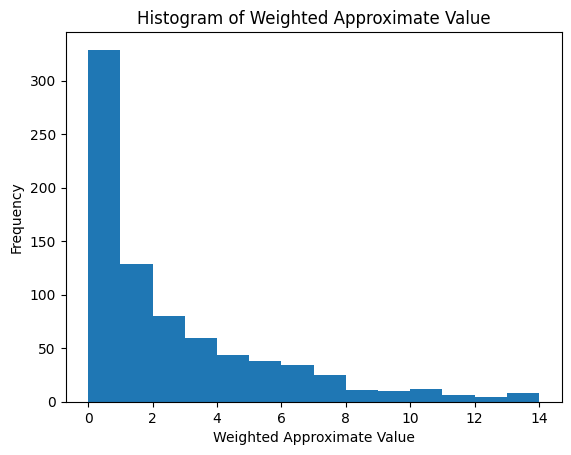

In [215]:
bin_width = 1

bins = np.arange(min(y_nona), max(y_nona) + bin_width, bin_width)

plt.hist(y_nona, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Weighted Approximate Value')
plt.title('Histogram of Weighted Approximate Value')
plt.show()

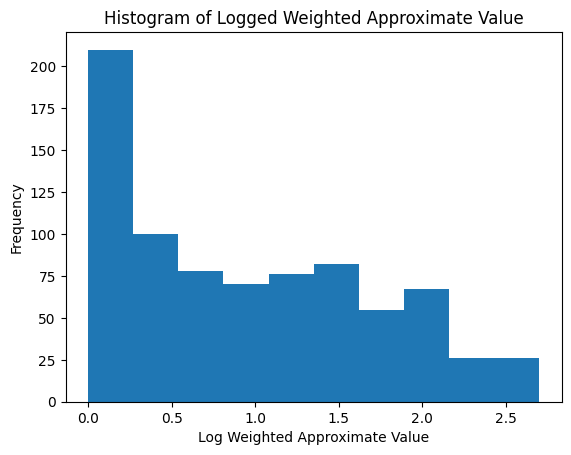

In [216]:
y_log = y_nona.copy()
y_log = np.log(y_log + 1)

plt.hist(y_log)
plt.ylabel('Frequency')
plt.xlabel('Log Weighted Approximate Value')
plt.title('Histogram of Logged Weighted Approximate Value')
plt.show()

In [217]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


train_x, test_x, train_y, test_y = train_test_split(X_nona, y_log, test_size = 0.3)

num_cols = train_x.select_dtypes(include=np.number).columns
cat_cols = train_x.select_dtypes(include='object').columns


# Create transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")

# Fit on training data, transform both
train_x = preprocessor.fit_transform(train_x)
test_x = preprocessor.transform(test_x)

In [218]:
train_x

,usage_overall,avg_ppa_all,total_ppa_all,fumbles_FUM,fumbles_LOST,passing_ATT,passing_COMPLETIONS,passing_PCT,INT_pct,passing_TD,passing_YDS,passing_YPA,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_TD,rushing_YDS,rushing_YPC,age,height,weight,position_x,conference
4360,-0.543016,-0.734515,-0.225713,0.765858,-0.055683,-0.394682,-0.391511,-0.44247,-0.191044,-0.37891,-0.39246,-0.420924,0.893475,0.811673,0.925169,0.345226,-0.707445,-0.658411,-0.631203,-0.758005,-0.555934,-0.081400,-0.616000,WR,PAC
893,-0.775891,0.200794,-0.524722,-0.350377,-0.296949,-0.394682,-0.391511,-0.44247,-0.191044,-0.37891,-0.39246,-0.420924,0.140385,0.335753,0.612278,1.418187,-0.691190,-0.658411,-0.602574,1.983744,-0.555934,-0.081400,-1.477483,WR,B12
475,-0.943137,0.623771,-0.926059,-0.350377,-0.296949,-0.394682,-0.391511,-0.44247,-0.191044,-0.37891,-0.39246,-0.420924,-0.550524,-0.425719,-0.571442,0.256485,-0.707445,-0.658411,-0.631203,-0.758005,0.384224,1.336370,1.787082,TE,B1G
5094,-0.443939,1.289325,0.798533,-0.350377,-0.296949,-0.394682,-0.391511,-0.44247,-0.191044,-0.37891,-0.39246,-0.420924,1.911874,3.257902,2.285554,1.064836,-0.707445,-0.658411,-0.631203,-0.758005,0.384224,-0.435842,-2.066918,WR,SEC
4562,-0.864806,0.250493,-0.679915,-0.350377,-0.296949,-0.394682,-0.391511,-0.44247,-0.191044,-0.37891,-0.39246,-0.420924,0.154203,0.621305,0.256090,0.509262,-0.707445,-0.658411,-0.631203,-0.758005,-1.496092,0.273042,1.106964,TE,SEC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1211,-0.803412,0.316055,-0.509457,-0.350377,-0.296949,-0.394682,-0.391511,-0.44247,-0.191044,-0.37891,-0.39246,-0.420924,0.320021,-0.140167,-0.065282,-0.033941,-0.707445,-0.658411,-0.631203,-0.758005,-1.496092,2.045255,2.059129,TE,B1G
868,-0.468920,0.359410,0.229945,-0.350377,-0.296949,-0.394682,-0.391511,-0.44247,-0.191044,-0.37891,-0.39246,-0.420924,1.826201,0.621305,1.700479,0.579180,-0.707445,-0.658411,-0.631203,-0.758005,0.384224,-0.081400,-0.298612,WR,PAC
130,-0.403291,-0.143933,0.122489,-0.350377,-0.296949,-0.394682,-0.391511,-0.44247,-0.191044,-0.37891,-0.39246,-0.420924,1.563656,0.716489,1.726367,0.821201,-0.585536,-0.466913,-0.404963,2.062080,1.324382,-0.435842,-0.752024,WR,MAC
4702,-0.703911,0.901878,-0.671811,-0.350377,-0.296949,-0.394682,-0.391511,-0.44247,-0.191044,-0.37891,-0.39246,-0.420924,-0.163615,0.478529,0.218597,1.122383,-0.707445,-0.658411,-0.631203,-0.758005,-0.555934,0.981927,0.608211,WR,SEC


In [222]:
from catboost import CatBoostRegressor

# finds categorical features
cat_features = train_x.select_dtypes(include=['object', 'category']).columns
cat_indices = [train_x.columns.get_loc(col) for col in cat_features]

model = CatBoostRegressor(
    iterations=2000,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    l2_leaf_reg = 10,
    verbose=100
)

model.fit(
    train_x,
    train_y,
    eval_set = (test_x, test_y),
    cat_features=cat_indices # assigns categorical features
)

preds = model.predict(test_x)

0:	learn: 0.7728928	test: 0.7583900	best: 0.7583900 (0)	total: 6.16ms	remaining: 12.3s
100:	learn: 0.6224245	test: 0.7029002	best: 0.7028201 (94)	total: 469ms	remaining: 8.81s
200:	learn: 0.5492502	test: 0.6980312	best: 0.6973338 (156)	total: 929ms	remaining: 8.31s
300:	learn: 0.4933711	test: 0.6986885	best: 0.6973338 (156)	total: 1.42s	remaining: 8s
400:	learn: 0.4455162	test: 0.6996282	best: 0.6973338 (156)	total: 1.88s	remaining: 7.48s
500:	learn: 0.4077044	test: 0.6996438	best: 0.6973338 (156)	total: 2.36s	remaining: 7.05s
600:	learn: 0.3767145	test: 0.6999097	best: 0.6973338 (156)	total: 2.83s	remaining: 6.58s
700:	learn: 0.3505331	test: 0.7026133	best: 0.6973338 (156)	total: 3.31s	remaining: 6.14s
800:	learn: 0.3247625	test: 0.7022294	best: 0.6973338 (156)	total: 3.78s	remaining: 5.66s
900:	learn: 0.3034831	test: 0.7043212	best: 0.6973338 (156)	total: 4.26s	remaining: 5.2s
1000:	learn: 0.2839293	test: 0.7045663	best: 0.6973338 (156)	total: 4.73s	remaining: 4.72s
1100:	learn: 0.26

In [223]:
print(f"{"="*10}Raw Predictions{"="*10}\n{preds}")
print(f"{"="*10}Exponentiated Predictions{"="*10}\n{np.exp(preds) - 1}")

==========Raw Predictions==========
[1.33014687 1.24504976 1.12048752 1.12084138 1.35560822 1.43824476
 0.67614304 0.7094061  0.4509246  1.16517522 1.38815028 0.92087976
 0.73126079 0.64502281 0.64626901 0.4833999  0.67558873 0.60634342
 0.96980321 0.7973728  1.12788552 0.5008432  1.09061926 0.56505721
 0.99424292 0.60193311 0.8915643  0.74096168 0.79547739 1.08790008
 0.48920506 0.78325076 0.67542245 1.0750958  1.43291574 0.41137123
 1.13524012 1.14782997 1.29987645 0.65915329 0.7568677  0.89612257
 1.09664922 1.2637783  0.45979654 0.80673444 1.5127923  0.67781047
 1.04363098 0.74630418 0.42136582 0.98916441 0.81503743 0.81692284
 0.84215017 0.83110414 0.96942472 0.65683563 0.74243261 1.32702926
 0.98635853 0.97532137 1.44597371 1.25796063 0.53908751 1.32498876
 0.57519229 0.91461702 1.25826299 0.72686864 0.49920637 0.95407007
 0.93358349 0.95219146 1.17338061 1.2737834  1.17782118 0.76084611
 1.06124645 0.48128332 0.49693751 0.76361072 0.94821545 0.90828514
 1.0518319  0.74140166 0.6

In [224]:
from sklearn.metrics import root_mean_squared_error as rmse
preds_exp = np.exp(preds) - 1
test_y_exp = np.exp(test_y) - 1

test_rmse = rmse(test_y_exp, preds_exp)

print(f"Test RMSE: {test_rmse:.2f}")

Test RMSE: 2.69


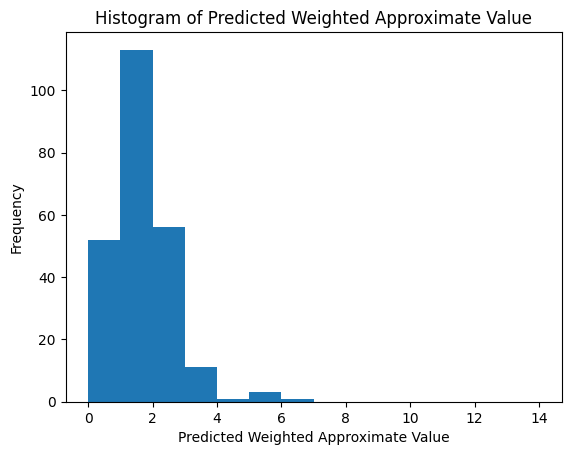

In [225]:
plt.hist(preds_exp, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Predicted Weighted Approximate Value')
plt.title('Histogram of Predicted Weighted Approximate Value')
plt.show()

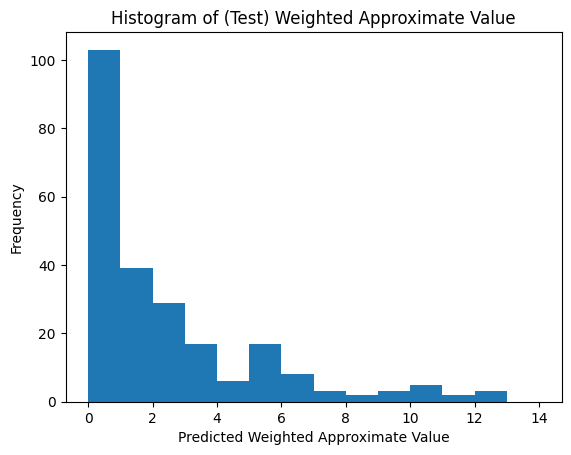

In [226]:
plt.hist(test_y_exp, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Predicted Weighted Approximate Value')
plt.title('Histogram of (Test) Weighted Approximate Value')
plt.show()

In [228]:
from sklearn.model_selection import KFold
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original) # Apply StandardScaler to numerical columns
        ],
        remainder='passthrough', # Keep categorical columns as they are for CatBoost
        verbose_feature_names_out=False
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = CatBoostRegressor(
        iterations=2000,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',
        verbose=1000,
        l2_leaf_reg = 10,
        random_seed=101 # Added random_seed for reproducibility
    )

    model.fit(
        X_train_processed,
        y_train_fold,
        eval_set = (X_val_processed, y_val_fold),
        cat_features=cat_indices_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

0:	learn: 0.7615862	test: 0.8176041	best: 0.8176041 (0)	total: 7.82ms	remaining: 15.6s
1000:	learn: 0.3062265	test: 0.7367422	best: 0.7231914 (173)	total: 6.38s	remaining: 6.37s
1999:	learn: 0.1839003	test: 0.7409859	best: 0.7231914 (173)	total: 11.4s	remaining: 0us

bestTest = 0.7231913745
bestIteration = 173

Shrink model to first 174 iterations.
0:	learn: 0.7641433	test: 0.8024851	best: 0.8024851 (0)	total: 5.52ms	remaining: 11s
1000:	learn: 0.3133638	test: 0.7354668	best: 0.7345717 (790)	total: 6.46s	remaining: 6.45s
1999:	learn: 0.1841648	test: 0.7317029	best: 0.7314573 (1794)	total: 11.5s	remaining: 0us

bestTest = 0.7314572866
bestIteration = 1794

Shrink model to first 1795 iterations.
0:	learn: 0.7684157	test: 0.7630714	best: 0.7630714 (0)	total: 6.08ms	remaining: 12.2s
1000:	learn: 0.3174315	test: 0.6941698	best: 0.6836515 (203)	total: 6.27s	remaining: 6.26s
1999:	learn: 0.1761649	test: 0.7067326	best: 0.6836515 (203)	total: 10.9s	remaining: 0us

bestTest = 0.6836514752
bestI

In [229]:
y_log.describe()

,adjusted_w_av
count,790.000000
mean,0.926980
std,0.772268
min,0.000000
25%,0.223144
50%,0.810930
75%,1.545783
max,2.699682


# RandomForest

In [230]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = RandomForestRegressor(
        n_estimators = 1000,
        max_features = 'sqrt'
    )

    model.fit(
        X_train_processed,
        y_train_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

CV RMSE: 2.75


# **XGBoost**

In [3]:
%%capture
! pip install xgboost

In [232]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
import xgboost as xgb
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = XGBRegressor(
        n_estimators = 1000,
        objective = 'reg:squarederror',
        learning_rate = 0.05,
        max_depth = 6,
        random_state = 101,
        reg_lambda = 5,
        eval_metric = 'rmse'
    )

    model.fit(
        X_train_processed,
        y_train_fold,
        eval_set = [(X_val_processed, y_val_fold)],
        verbose = 1000
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

[0]	validation_0-rmse:0.81638
[999]	validation_0-rmse:0.76985
[0]	validation_0-rmse:0.80013
[999]	validation_0-rmse:0.78804
[0]	validation_0-rmse:0.75967
[999]	validation_0-rmse:0.75287
[0]	validation_0-rmse:0.72359
[999]	validation_0-rmse:0.72237
[0]	validation_0-rmse:0.74848
[999]	validation_0-rmse:0.70161
[0]	validation_0-rmse:0.72682
[999]	validation_0-rmse:0.67907
[0]	validation_0-rmse:0.82438
[999]	validation_0-rmse:0.75349
[0]	validation_0-rmse:0.78265
[999]	validation_0-rmse:0.76562
[0]	validation_0-rmse:0.78780
[999]	validation_0-rmse:0.74051
[0]	validation_0-rmse:0.68916
[999]	validation_0-rmse:0.69158
CV RMSE: 2.75
